In [ ]:
# ==========================================
# LANGKAH 1: MEMUAT DAN MENGEKSPLORASI DATA
# ==========================================
import pandas as pd
import numpy as np
import os

# Menggunakan metode pelacakan folder otomatis milikmu
notebook_dir = os.getcwd()
base_dir = os.path.dirname(notebook_dir)

# Secara otomatis menggabungkan folder DATASET dan nama file excel baru kamu
file_path = os.path.join(base_dir, "DATASET", "data greenline 2024 sd juni 2026.xlsx")

print(f"Sedang mencari dan membaca master file di: {file_path}")

# Sistem backup otomatis jika letak notebook kamu agak bergeser
if not os.path.exists(file_path):
    # Coba cari di folder DATASET langsung tanpa naik satu level (base_dir)
    file_path = os.path.join("DATASET", "data greenline 2024 sd juni 2026.xlsx")

# Eksekusi pembacaan sheet tunggal Excel
df_raw = pd.read_excel(file_path, sheet_name="RAW per STASIUN")

# Bersihkan spasi gaib pada nama kolom jika ada
df_raw.columns = df_raw.columns.str.strip()

print("\n✅ BERHASIL! MASTER DATA TELAH TERMUAT TANPA ERROR.")
print(f"Total Data Historis Lintas Greenline: {len(df_raw)} baris")
print("\n=== STRUKTUR DATA ASLI KEMENHUB ===")
df_raw.info()


Sedang mencari dan membaca master file di: c:\Users\HP\Documents\Tito\BAB IV\DATASET\data greenline 2024 sd juni 2026.xlsx

✅ BERHASIL! MASTER DATA TELAH TERMUAT TANPA ERROR.
Total Data Historis Lintas Greenline: 13238 baris

=== STRUKTUR DATA ASLI KEMENHUB ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13238 entries, 0 to 13237
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   tanggal                      13238 non-null  datetime64[ns]
 1   nama_stasiun                 13238 non-null  object        
 2   penumpang_berangkat_komuter  13238 non-null  int64         
 3   penumpang_datang_komuter     13238 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 413.8+ KB


In [ ]:
# =======================================================
# LANGKAH 1.5: ANALISIS DAN RINGKASAN TOTAL 20 STASIUN
# =======================================================

df_summary = df_raw.copy()

# Pastikan data bertipe integer numerik bersih
df_summary['penumpang_berangkat_komuter'] = pd.to_numeric(df_summary['penumpang_berangkat_komuter'], errors='coerce').fillna(0).astype(int)
df_summary['penumpang_datang_komuter'] = pd.to_numeric(df_summary['penumpang_datang_komuter'], errors='coerce').fillna(0).astype(int)
df_summary['volume_penumpang'] = df_summary['penumpang_berangkat_komuter'] + df_summary['penumpang_datang_komuter']

# Hitung agregasi total untuk tiap stasiun
tabel_stasiun = df_summary.groupby('nama_stasiun').agg({
    'penumpang_berangkat_komuter': 'sum',
    'penumpang_datang_komuter': 'sum',
    'volume_penumpang': 'sum'
}).reset_index()

# Urutkan stasiun berdasarkan volume penumpang terbesar
tabel_stasiun = tabel_stasiun.sort_values(by='volume_penumpang', ascending=False).reset_index(drop=True)

# Hitung persentase kontribusi per stasiun
total_volume_lintas = tabel_stasiun['volume_penumpang'].sum()
tabel_stasiun['Persentase (%)'] = (tabel_stasiun['volume_penumpang'] / total_volume_lintas) * 100

# Buat baris Total Akhir
baris_total = pd.DataFrame({
    'nama_stasiun': ['TOTAL KESELURUHAN'],
    'penumpang_berangkat_komuter': [tabel_stasiun['penumpang_berangkat_komuter'].sum()],
    'penumpang_datang_komuter': [tabel_stasiun['penumpang_datang_komuter'].sum()],
    'volume_penumpang': [total_volume_lintas],
    'Persentase (%)': [100.0]
})

tabel_akhir = pd.concat([tabel_stasiun, baris_total], ignore_index=True)

# Format angka ribuan agar rapi
tabel_tampilan = tabel_akhir.copy()
for col in ['penumpang_berangkat_komuter', 'penumpang_datang_komuter', 'volume_penumpang']:
    tabel_tampilan[col] = tabel_tampilan[col].astype(int).map('{:,}'.format)
tabel_tampilan['Persentase (%)'] = tabel_tampilan['Persentase (%)'].astype(float).map('{:.2f} %'.format)

tabel_tampilan.columns = ['Nama Stasiun', 'Total Penumpang Berangkat', 'Total Penumpang Datang', 'Total Volume Penumpang', 'Persentase Kontribusi']
print(tabel_tampilan.to_string(index=False))



     Nama Stasiun Total Penumpang Berangkat Total Penumpang Datang Total Volume Penumpang Persentase Kontribusi
       TANAHABANG                27,878,581             24,658,711             52,537,292               20.85 %
         PALMERAH                11,770,054             12,444,608             24,214,662                9.61 %
        KEBAYORAN                11,046,710             11,864,086             22,910,796                9.09 %
       RAWA BUNTU                10,937,839             10,721,792             21,659,631                8.60 %
         SUDIMARA                 9,790,532              9,807,220             19,597,752                7.78 %
    RANGKASBITUNG                 8,002,948              7,441,786             15,444,734                6.13 %
    PARUNGPANJANG                 7,566,231              7,616,074             15,182,305                6.03 %
      JURANGMANGU                 7,260,694              7,538,049             14,798,743               

In [6]:
# ==========================================
# LANGKAH 2: PREPROCESSING & FEATURE ENGINEERING
# ==========================================

df_clean = df_raw.copy()

# 1. Validasi tipe data
df_clean['penumpang_berangkat_komuter'] = pd.to_numeric(df_clean['penumpang_berangkat_komuter'], errors='coerce').fillna(0).astype(int)
df_clean['penumpang_datang_komuter'] = pd.to_numeric(df_clean['penumpang_datang_komuter'], errors='coerce').fillna(0).astype(int)
df_clean['volume_penumpang'] = df_clean['penumpang_berangkat_komuter'] + df_clean['penumpang_datang_komuter']

# 2. Konversi format waktu & pengurutan kronologis
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])
df_clean = df_clean.sort_values(by=['nama_stasiun', 'tanggal']).reset_index(drop=True)

# 3. Rekayasa Fitur Kalender
df_clean['day_of_week'] = df_clean['tanggal'].dt.dayofweek
df_clean['month'] = df_clean['tanggal'].dt.month
df_clean['is_weekend'] = df_clean['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 4. Rekayasa Fitur Historis (Lag Features)
df_clean['lag_1'] = df_clean.groupby('nama_stasiun')['volume_penumpang'].shift(1)
df_clean['lag_7'] = df_clean.groupby('nama_stasiun')['volume_penumpang'].shift(7)

# Hapus baris kosong akibat pergeseran lag
df_clean = df_clean.dropna().reset_index(drop=True)

# 5. One-Hot Encoding Kategori Stasiun
df_encoded = pd.get_dummies(df_clean, columns=['nama_stasiun'], drop_first=False)

# 6. Pemilihan Variabel Prediktor
fitur_waktu = ['day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_7']
fitur_stasiun = [col for col in df_encoded.columns if col.startswith('nama_stasiun_')]
fitur_pilihan = fitur_waktu + fitur_stasiun

# 7. Pembagian Data 80:20 Berdasarkan Urutan Waktu
unique_dates = sorted(df_clean['tanggal'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_df = df_encoded[df_encoded['tanggal'] < split_date]
test_df = df_encoded[df_encoded['tanggal'] >= split_date]

X_train = train_df[fitur_pilihan]
y_train = train_df['volume_penumpang']
X_test = test_df[fitur_pilihan]
y_test = test_df['volume_penumpang']

print("=== SPLIT KRONOLOGIS SUKSES ===")
print(f"Batas Waktu Pembagian Data: {split_date.strftime('%Y-%m-%d')}")
print(f"Data Latih (X_train): {X_train.shape[0]} baris | Data Uji (X_test): {X_test.shape[0]} baris")

=== SPLIT KRONOLOGIS SUKSES ===
Batas Waktu Pembagian Data: 2026-01-19
Data Latih (X_train): 10374 baris | Data Uji (X_test): 2724 baris


=== HASIL EVALUASI MODEL RANDOM FOREST REGRESSION ===
DATA LATIH -> MAE: 1384.28 | RMSE: 2977.57 | R2: 0.9768
DATA UJI   -> MAE: 2419.97 | RMSE: 4835.60 | R2: 0.9383


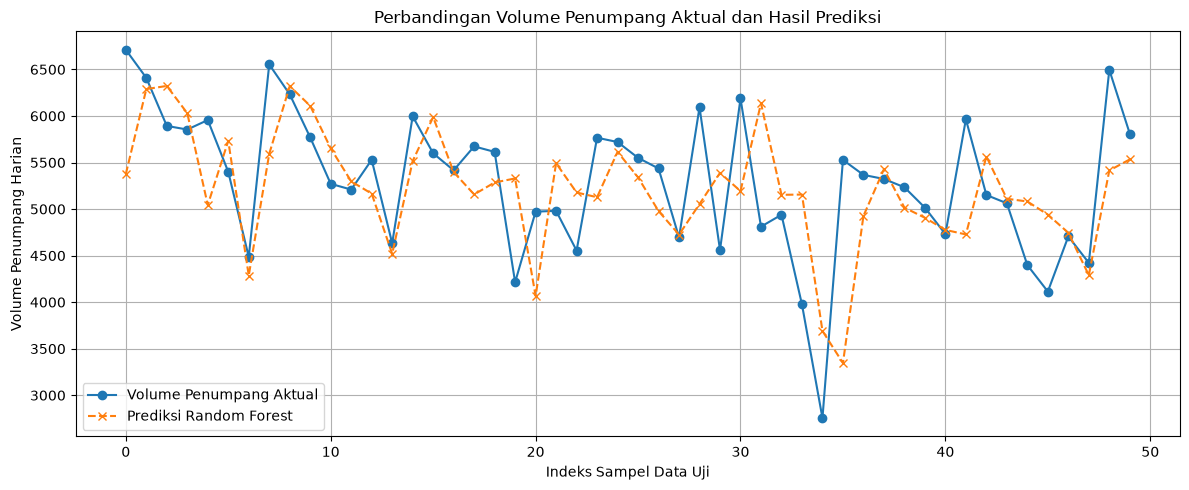

In [8]:
# ==========================================
# PEMODELAN DAN EVALUASI RANDOM FOREST
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 1. Membentuk model berdasarkan parameter terbaik
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# 2. Melatih model
rf_model.fit(X_train, y_train)

# 3. Membuat prediksi
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 4. Menghitung evaluasi data latih
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# 5. Menghitung evaluasi data uji
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# 6. Menampilkan hasil evaluasi
print("=== HASIL EVALUASI MODEL RANDOM FOREST REGRESSION ===")

print(
    f"DATA LATIH -> MAE: {mae_train:.2f} | "
    f"RMSE: {rmse_train:.2f} | "
    f"R2: {r2_train:.4f}"
)

print(
    f"DATA UJI   -> MAE: {mae_test:.2f} | "
    f"RMSE: {rmse_test:.2f} | "
    f"R2: {r2_test:.4f}"
)

# 7. Visualisasi 50 sampel pertama data uji
y_test_plot = np.asarray(y_test)[:50]
y_pred_plot = y_pred_test[:50]

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_plot,
    label="Volume Penumpang Aktual",
    marker="o"
)

plt.plot(
    y_pred_plot,
    label="Prediksi Random Forest",
    marker="x",
    linestyle="--"
)

plt.title("Perbandingan Volume Penumpang Aktual dan Hasil Prediksi")
plt.xlabel("Indeks Sampel Data Uji")
plt.ylabel("Volume Penumpang Harian")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# LANGKAH 5: EKSPOR MODEL BINER
# ==========================================
import joblib

joblib.dump(rf_model, 'model_rf_greenline.joblib')
joblib.dump(fitur_pilihan, 'model_features.joblib')
joblib.dump(sorted(df_clean['nama_stasiun'].unique()), 'stations_list.joblib')

print("🎉 Selesai! Model dan seluruh file pendukung dashboard sukses disimpan.")
print("Sekarang kamu bisa langsung menjalankan dashboard Streamlit app.py tanpa takut error.")

🎉 Selesai! Model dan seluruh file pendukung dashboard sukses disimpan.
Sekarang kamu bisa langsung menjalankan dashboard Streamlit app.py tanpa takut error.
